# Introduction
Predict 5,000 stocks: Will the Close price rise or fall in 30 days?  
https://www.kaggle.com/competitions/predicting-stock-trends-rise-or-fall

## Goal
Predict whether a stock's **closing price** will be above or below its current value after 30 trading days.

## Data
OHLC (Open, High, Low, Close) data
* Tickers: 5,000
  * `ticker_1` - `ticker_5000`
* Columns: 9
* Columns Details:
  * Date — The date corresponding to the stock data entry.
  * Open — Opening price of the stock on that date.
  * High — Highest price of the stock on that date.
  * Low — Lowest price of the stock on that date.
  * Close — Closing price of the stock on that date.
  * Volume — Number of shares traded on that date.
  * Dividends — Dividend payout value for that date.
  * Stock Splits — Any stock splits that occurred on that date.
  * Ticker — The unique identifier for the stock.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import datetime
import xgboost as xgb
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_validate, cross_val_score, KFold, GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/predicting-stock-trends-rise-or-fall/sample_submission.csv
/kaggle/input/predicting-stock-trends-rise-or-fall/train.csv
/kaggle/input/predicting-stock-trends-rise-or-fall/test.csv


# Load Data

## Define training period

In [2]:
# Since train.csv contains data for 42 years since 1962, which is too much data, only the most recent 4 years are used.
TRAIN_FROM = "2020-01-01"

## Load csv files

In [3]:
data_path = dirname

In [4]:
df_train = pd.read_csv(f"{data_path}/train.csv", parse_dates=["Date"])

In [5]:
df_test = pd.read_csv(f"{data_path}/test.csv", parse_dates=["Date"])

In [6]:
df_submission = pd.read_csv(f"{data_path}/sample_submission.csv")

In [7]:
df_train = df_train[df_train["Date"] >= TRAIN_FROM]

In [8]:
df_train.head()

,Ticker,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
15634152,ticker_1584,2020-01-02,2.880000,2.890000,2.780000,2.850000,160700.0,0.0,0.0
15634153,ticker_537,2020-01-02,2.715853,2.724235,2.707471,2.715853,177000.0,0.0,0.0
15634154,ticker_3092,2020-01-02,4.220000,4.300000,4.010000,4.100000,770400.0,0.0,0.0
15634155,ticker_2328,2020-01-02,6.560000,6.640000,6.560000,6.600000,497800.0,0.0,0.0
15634156,ticker_1688,2020-01-02,36.885158,37.033328,35.736836,35.931309,2581100.0,0.0,0.0


In [9]:
df_train.tail()

,Ticker,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
21033517,ticker_2098,2024-09-23,15.230000,15.230000,14.690000,14.780000,63400.0,0.0,0.0
21033518,ticker_3748,2024-09-23,24.700001,24.768400,24.510000,24.570000,31208.0,0.0,0.0
21033519,ticker_2615,2024-09-23,11.090000,11.150000,10.960000,11.090000,1014300.0,0.0,0.0
21033520,ticker_4765,2024-09-23,25.200001,25.202999,25.129999,25.134001,4500.0,0.0,0.0
21033521,ticker_4658,2024-09-23,0.281000,0.290000,0.264000,0.270000,272200.0,0.0,0.0


# EDA

## Check the shape of the data

In [10]:
print("Train data shape:", df_train.shape)
print("Test data shape:", df_test.shape)

Train data shape: (5399370, 9)
Test data shape: (5000, 2)


## Display basic info

In [11]:
print("\nTrain data info:")
df_train.info()
print("\nTest data info:")
df_test.info()


Train data info:
<class 'pandas.core.frame.DataFrame'>
Index: 5399370 entries, 15634152 to 21033521
Data columns (total 9 columns):
 #   Column        Dtype         
---  ------        -----         
 0   Ticker        object        
 1   Date          datetime64[ns]
 2   Open          float64       
 3   High          float64       
 4   Low           float64       
 5   Close         float64       
 6   Volume        float64       
 7   Dividends     float64       
 8   Stock Splits  float64       
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 411.9+ MB

Test data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ID      5000 non-null   object        
 1   Date    5000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), object(1)
memory usage: 78.3+ KB


## Describe numerical features

In [12]:
print("\nTrain data description:")
print(df_train.describe())
print("\nTest data description:")
print(df_test.describe())


Train data description:
                                Date          Open          High  \
count                        5399370  5.399370e+06  5.399370e+06   
mean   2022-06-28 07:17:22.293601024  3.508435e+01  3.565642e+01   
min              2020-01-02 00:00:00  1.000000e-02  7.900000e-02   
25%              2021-05-17 00:00:00  8.440000e+00  8.640000e+00   
50%              2022-07-19 00:00:00  1.860000e+01  1.893000e+01   
75%              2023-08-25 00:00:00  4.023000e+01  4.096000e+01   
max              2024-09-23 00:00:00  8.319200e+02  1.010080e+03   
std                              NaN  4.672713e+01  4.738703e+01   

                Low         Close        Volume     Dividends  Stock Splits  
count  5.399370e+06  5.399370e+06  5.399370e+06  5.399370e+06  5.399370e+06  
mean   3.449780e+01  3.506855e+01  1.343830e+06  9.107154e-04  3.904059e-05  
min    0.000000e+00  7.851000e-02  0.000000e+00  0.000000e+00  0.000000e+00  
25%    8.240000e+00  8.430000e+00  4.900000e+04  0

## Check fo missing values

In [13]:
print("\nTrain data missing values:")
print(df_train.isnull().sum())
print("\nTest data missing values:")
print(df_test.isnull().sum())


Train data missing values:
Ticker          0
Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

Test data missing values:
ID      0
Date    0
dtype: int64


## Analyze 'Open', 'High', 'Low', 'Close' features

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

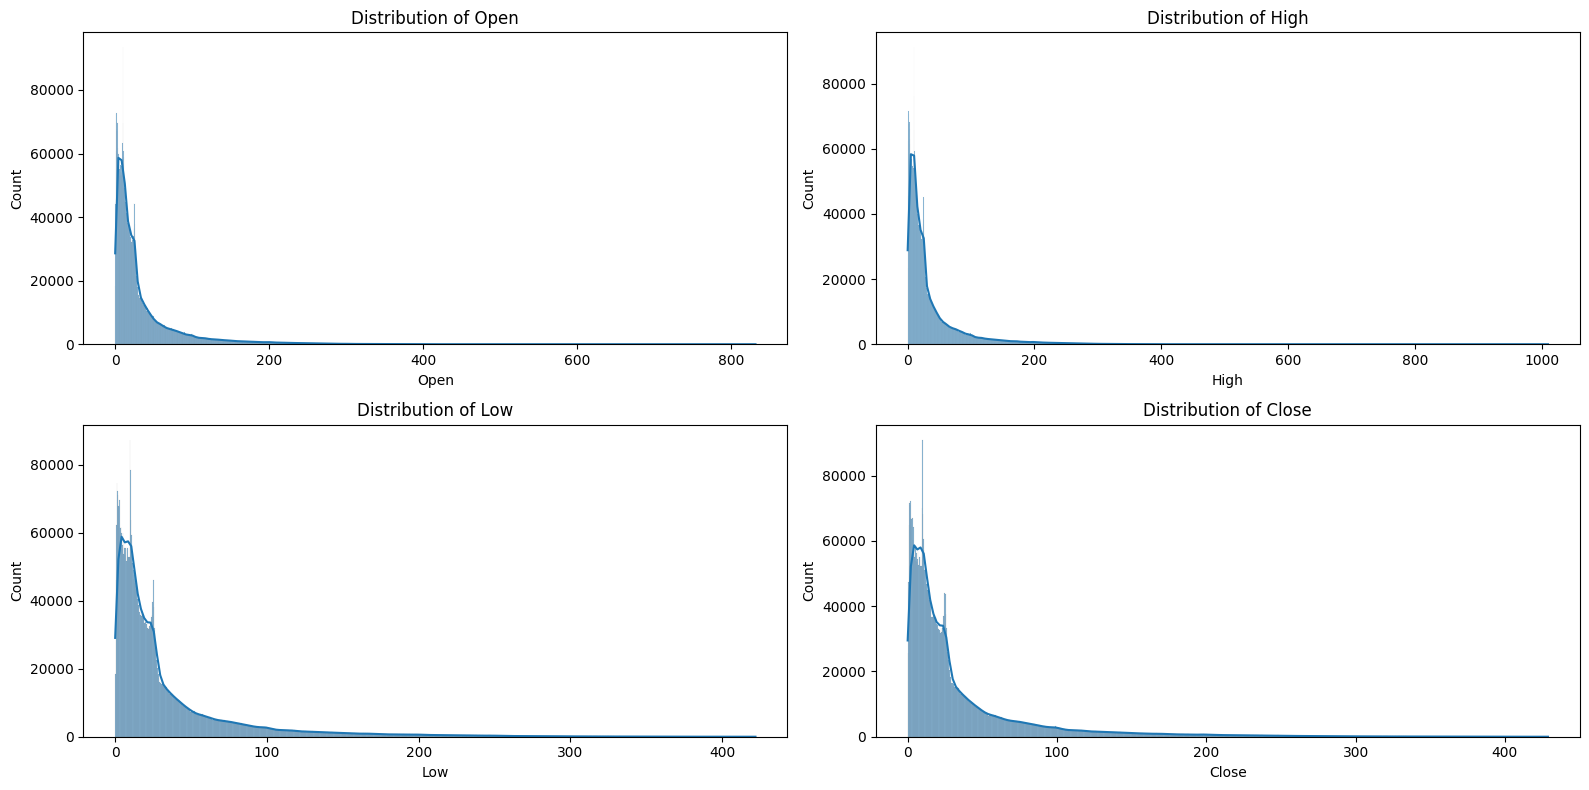

In [14]:
plt.figure(figsize=(16, 8))
for i, col in enumerate(["Open", "High", "Low", "Close"]):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df_train[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## Relationship between features

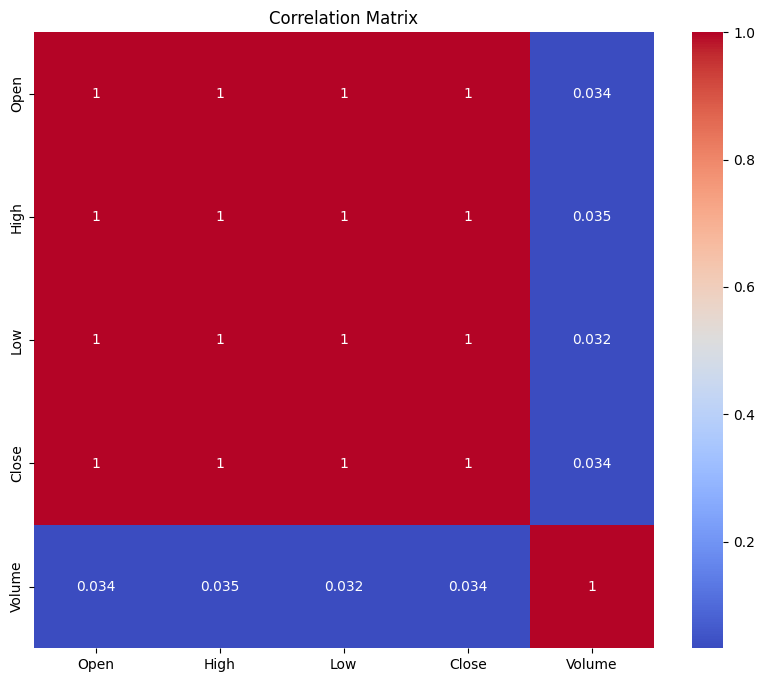

In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_train[['Open', 'High', 'Low', 'Close', 'Volume']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Time series analysis of Close price

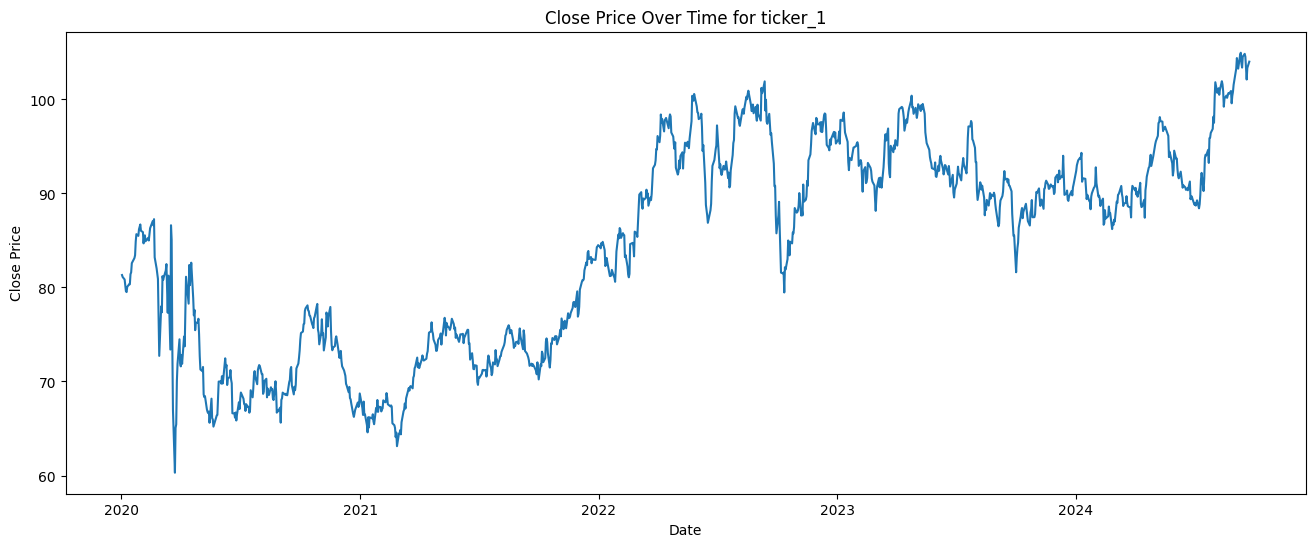

In [16]:
plt.figure(figsize=(16, 6))
plt.plot(df_train[df_train["Ticker"] == "ticker_1"]["Date"], df_train[df_train["Ticker"] == "ticker_1"]["Close"])
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Close Price Over Time for ticker_1')
plt.show()

# Feature Engineering
Use technical indicators as features
* Daily return
  * The percentage change in its value from the previous day's closing price
* Moving average
  * A stock indicator commonly used in technical analysis, used to help smooth out price data by creating a constantly updated average price
* Volatility
  * Shares in companies which experience sharp price movements over short periods of time

## Create Features

In [17]:
# Create Label: Get the closing price after 30 business days for each stock, 1 if up, 0 if down
df_train = df_train.sort_values(["Ticker", "Date"])
df_train["future_close"] = df_train.groupby("Ticker")["Close"].shift(-30)

In [18]:
def create_features(df: pd.DataFrame) -> pd.DataFrame:
    print("Sorting values...")
    df = df.sort_values(["Ticker", "Date"])

    # Daily return
    print("Calculating daily returns...")
    df["ret_1"] = df.groupby("Ticker")["Close"].pct_change(1)

    # Moving average (5, 10, 20 days)
    print("Calculating moving averages...")
    for w in [5, 10, 20]:
        df[f"ma_{w}"] = df.groupby("Ticker")["Close"].transform(lambda x: x.rolling(w).mean())

    # volatility (5, 10, 20 days)
    print("Calculating volatilities...")
    for w in [5,10,20]:
        df[f'vol_{w}'] = df.groupby('Ticker')['ret_1'].transform(lambda x: x.rolling(w).std())

    return df

In [19]:
df_train = create_features(df_train)

Sorting values...
Calculating daily returns...
Calculating moving averages...
Calculating volatilities...


In [20]:
df_train.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Ticker,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,future_close,ret_1,ma_5,ma_10,ma_20,vol_5,vol_10,vol_20
15634707,ticker_1,2020-01-02,82.870760,82.962278,80.967157,81.324081,1335100.0,0.0,0.0,86.302719,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15641415,ticker_1,2020-01-03,81.049508,81.662693,80.957990,81.113571,1379600.0,0.0,0.0,87.054695,-0.002589,NaN,NaN,NaN,NaN,NaN,NaN
15643580,ticker_1,2020-01-06,81.150183,81.507108,80.628523,80.848167,1395300.0,0.0,0.0,86.621040,-0.003272,NaN,NaN,NaN,NaN,NaN,NaN
15646287,ticker_1,2020-01-07,80.537016,81.067830,79.786558,80.235001,1897700.0,0.0,0.0,87.266922,-0.007584,NaN,NaN,NaN,NaN,NaN,NaN
15651261,ticker_1,2020-01-08,79.695025,79.969578,79.338100,79.594353,2255000.0,0.0,0.0,83.207138,-0.007985,80.623035,NaN,NaN,NaN,NaN,NaN


In [21]:
df_train.tail()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Ticker,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,future_close,ret_1,ma_5,ma_10,ma_20,vol_5,vol_10,vol_20
21010467,ticker_999,2024-09-17,87.059998,88.120003,87.059998,87.709999,997900.0,0.0,0.0,NaN,0.009553,85.925998,84.388999,84.756499,0.005079,0.007838,0.017540
21014125,ticker_999,2024-09-18,87.720001,87.959999,86.680000,86.870003,757100.0,0.0,0.0,NaN,-0.009577,86.429999,84.770999,84.766999,0.009428,0.009242,0.017685
21019828,ticker_999,2024-09-19,88.220001,89.089996,87.680000,88.800003,885900.0,0.0,0.0,NaN,0.022217,87.164000,85.353999,84.873999,0.011999,0.010525,0.018352
21026462,ticker_999,2024-09-20,89.019997,90.070000,88.610001,89.910004,1665400.0,0.0,0.0,NaN,0.012500,88.034001,86.112000,85.031000,0.011921,0.009282,0.018520
21032385,ticker_999,2024-09-23,90.070000,90.239998,89.480003,89.989998,569600.0,0.0,0.0,NaN,0.000890,88.656001,86.809000,85.116500,0.012046,0.009623,0.018159


## Visualization

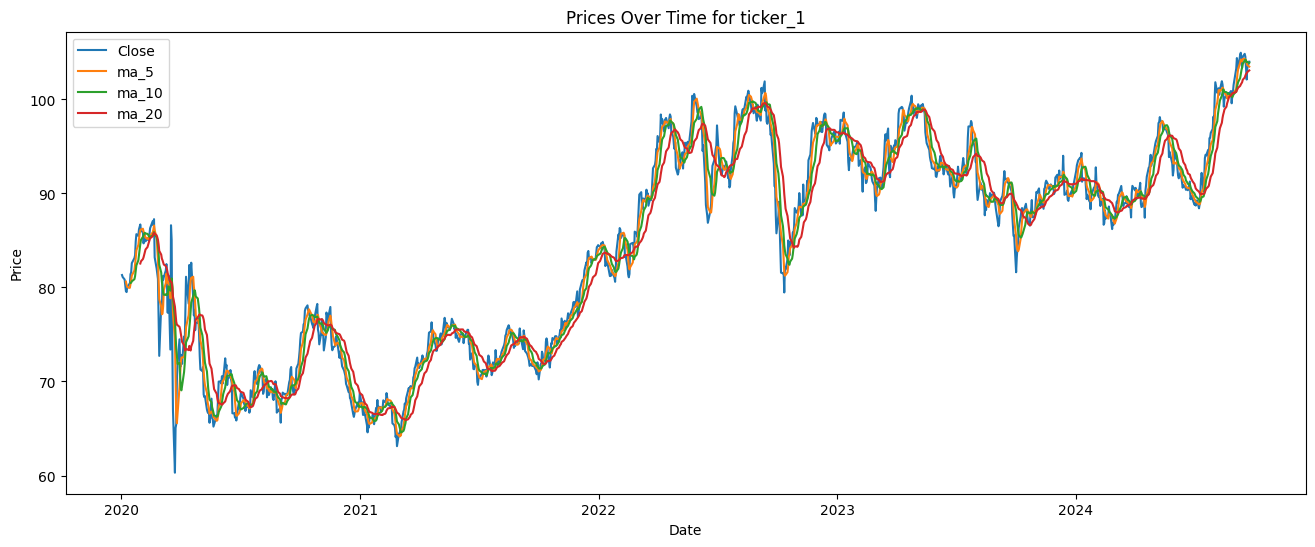

In [22]:
plt.figure(figsize=(16, 6))
plt.plot(df_train[df_train["Ticker"] == "ticker_1"]["Date"], df_train[df_train["Ticker"] == "ticker_1"]["Close"], label="Close")
plt.plot(df_train[df_train["Ticker"] == "ticker_1"]["Date"], df_train[df_train["Ticker"] == "ticker_1"]["ma_5"], label="ma_5")
plt.plot(df_train[df_train["Ticker"] == "ticker_1"]["Date"], df_train[df_train["Ticker"] == "ticker_1"]["ma_10"], label="ma_10")
plt.plot(df_train[df_train["Ticker"] == "ticker_1"]["Date"], df_train[df_train["Ticker"] == "ticker_1"]["ma_20"], label="ma_20")
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Prices Over Time for ticker_1')
plt.legend(loc='best')
plt.show()

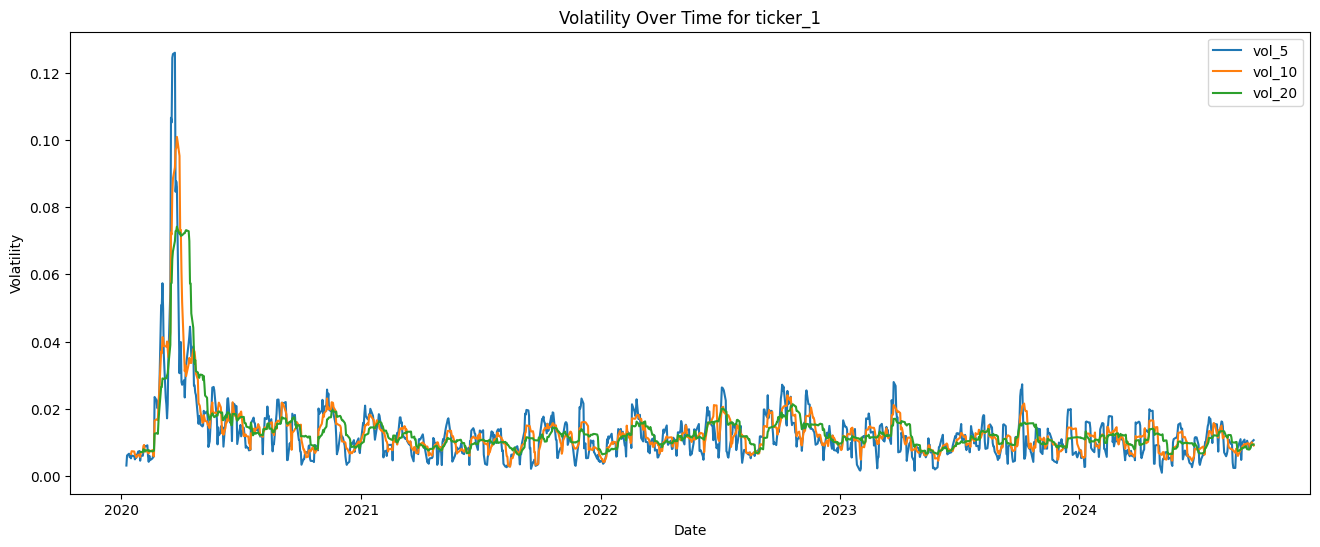

In [23]:
plt.figure(figsize=(16, 6))
plt.plot(df_train[df_train["Ticker"] == "ticker_1"]["Date"], df_train[df_train["Ticker"] == "ticker_1"]["vol_5"], label="vol_5")
plt.plot(df_train[df_train["Ticker"] == "ticker_1"]["Date"], df_train[df_train["Ticker"] == "ticker_1"]["vol_10"], label="vol_10")
plt.plot(df_train[df_train["Ticker"] == "ticker_1"]["Date"], df_train[df_train["Ticker"] == "ticker_1"]["vol_20"], label="vol_20")
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.title('Volatility Over Time for ticker_1')
plt.legend(loc='best')
plt.show()

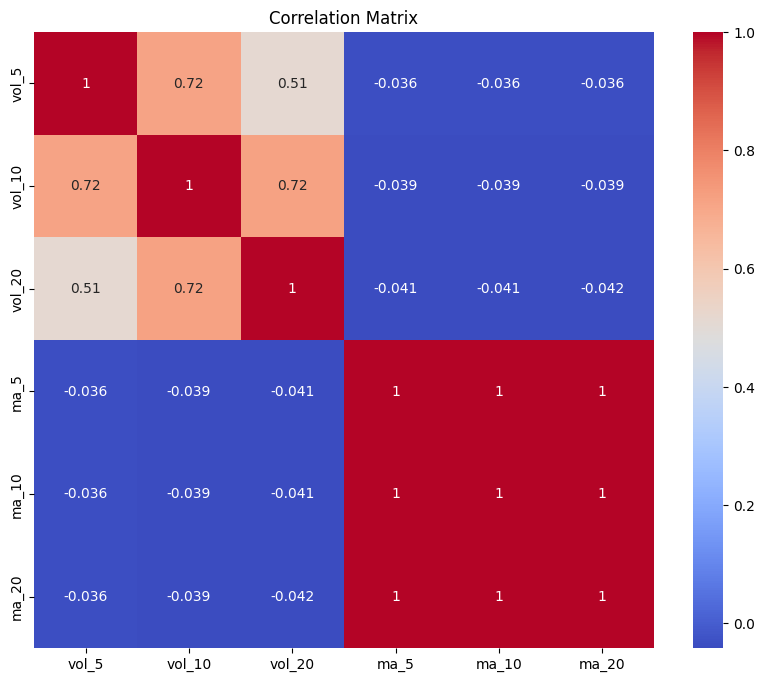

In [24]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_train[['vol_5', 'vol_10', 'vol_20', 'ma_5', 'ma_10', 'ma_20']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Model Training

In [25]:
df_train_features = df_train.dropna()

In [26]:
df_train_features.head()

,Ticker,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,future_close,ret_1,ma_5,ma_10,ma_20,vol_5,vol_10,vol_20
15709383,ticker_1,2020-01-31,86.613891,87.034879,85.616334,86.028168,3781500.0,0.0,0.0,73.399071,-0.007811,86.169101,85.056226,82.781971,0.006076,0.007172,0.007148
15715058,ticker_1,2020-02-03,86.174599,86.321026,85.424134,85.890884,1434400.0,0.0,0.0,86.621040,-0.001596,86.249638,85.386611,83.020837,0.006014,0.007051,0.007112
15716110,ticker_1,2020-02-04,85.781061,86.083069,84.655370,84.691978,1631900.0,0.0,0.0,85.070946,-0.013958,85.949457,85.543109,83.213027,0.007338,0.008941,0.007951
15721090,ticker_1,2020-02-05,84.563849,85.561406,84.362505,85.479042,1270800.0,0.0,0.0,73.897301,0.009293,85.759096,85.748111,83.475229,0.009098,0.009237,0.007733
15722857,ticker_1,2020-02-06,85.634632,85.991556,85.323469,85.543114,1212700.0,0.0,0.0,66.977219,0.000750,85.526637,85.812175,83.772667,0.008801,0.007539,0.007303


In [27]:
df_train_features.tail()

,Ticker,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,future_close,ret_1,ma_5,ma_10,ma_20,vol_5,vol_10,vol_20
20860895,ticker_999,2024-08-05,77.559998,79.220001,76.980003,79.099998,777200.0,0.0,0.0,87.709999,-0.020191,81.860001,84.455001,85.483001,0.027185,0.021328,0.016789
20864330,ticker_999,2024-08-06,79.300003,81.349998,78.949997,80.949997,1572600.0,0.0,0.0,86.870003,0.023388,81.550000,83.804001,85.300500,0.024080,0.023684,0.017745
20869335,ticker_999,2024-08-07,82.349998,82.470001,79.820000,80.209999,741700.0,0.0,0.0,88.800003,-0.009141,80.725999,83.200001,85.047501,0.019313,0.023590,0.017650
20878678,ticker_999,2024-08-08,80.669998,81.389999,80.610001,81.309998,1008600.0,0.0,0.0,89.910004,0.013714,80.459999,82.633000,84.828500,0.020697,0.024026,0.017962
20880467,ticker_999,2024-08-09,81.379997,81.599998,81.019997,81.559998,668700.0,0.0,0.0,89.989998,0.003075,80.625998,82.056000,84.574500,0.017409,0.023982,0.017732


In [28]:
df_train_features.describe()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,future_close,ret_1,ma_5,ma_10,ma_20,vol_5,vol_10,vol_20
count,5149420,5.149420e+06,5.149420e+06,5.149420e+06,5.149420e+06,5.149420e+06,5.149420e+06,5.149420e+06,5.149420e+06,5.149420e+06,5.149420e+06,5.149420e+06,5.149420e+06,5.149420e+06,5.149420e+06,5.149420e+06
mean,2022-06-19 10:17:01.234391296,3.509441e+01,3.566919e+01,3.450509e+01,3.507890e+01,1.348850e+06,9.328381e-04,4.061711e-05,3.517593e+01,5.806930e-04,3.507809e+01,3.507713e+01,3.507145e+01,2.839365e-02,3.007017e-02,3.139619e-02
min,2020-01-31 00:00:00,1.000000e-02,8.280000e-02,0.000000e+00,7.851000e-02,0.000000e+00,0.000000e+00,0.000000e+00,7.851000e-02,-9.800000e-01,8.793200e-02,9.070600e-02,9.243600e-02,0.000000e+00,0.000000e+00,0.000000e+00
25%,2021-05-24 00:00:00,8.490000e+00,8.690000e+00,8.280000e+00,8.478995e+00,4.915700e+04,0.000000e+00,0.000000e+00,8.328475e+00,-1.361029e-02,8.493266e+00,8.515500e+00,8.560000e+00,1.136513e-02,1.330952e-02,1.455597e-02
50%,2022-07-08 00:00:00,1.862747e+01,1.896000e+01,1.828000e+01,1.861000e+01,2.367000e+05,0.000000e+00,0.000000e+00,1.852000e+01,0.000000e+00,1.862800e+01,1.864700e+01,1.867950e+01,2.037171e-02,2.240187e-02,2.376890e-02
75%,2023-08-01 00:00:00,4.029000e+01,4.101893e+01,3.955000e+01,4.027692e+01,9.120000e+05,0.000000e+00,0.000000e+00,4.035607e+01,1.291426e-02,4.029000e+01,4.029600e+01,4.032409e+01,3.502003e-02,3.701172e-02,3.873485e-02
max,2024-08-09 00:00:00,5.815000e+02,8.016000e+02,4.213800e+02,4.288500e+02,1.123003e+09,1.875000e+01,1.000000e+01,4.288500e+02,2.573333e+02,4.233880e+02,4.199430e+02,4.132470e+02,1.150886e+02,8.138269e+01,5.754219e+01
std,NaN,4.659251e+01,4.724952e+01,4.592602e+01,4.658284e+01,5.542293e+06,2.848575e-02,1.278843e-02,4.697873e+01,1.261757e-01,4.654154e+01,4.649557e+01,4.640128e+01,1.230548e-01,1.226205e-01,1.224716e-01


In [29]:
# Separate Target Variable (future_close) and Ticker
# Rows with non-zero Stock Splits are quite few, so they are excluded from the features.
X = df_train_features.drop(["Ticker", "future_close", "Date", "Stock Splits"], axis=1)
y = df_train_features.future_close

In [30]:
# Separate data to train data and validation data
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
# Train the Model
model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

In [32]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [33]:
# Predict with validation data
from sklearn.metrics import mean_absolute_error

val_predictions = model.predict(X_valid)
val_mae = mean_absolute_error(y_valid, val_predictions)
print(f"MAE with validation data: {val_mae}")

MAE with validation data: 3.6953517151908994


# Cross Validation

In [34]:
scores = []

In [35]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [36]:
for train_idx, valid_idx in kf.split(X):
    X_cv_train, y_cv_train = X.iloc[train_idx], y.iloc[train_idx]
    X_cv_valid, y_cv_valid = X.iloc[valid_idx], y.iloc[valid_idx]

    model.fit(X_cv_train, y_cv_train)
    preds = model.predict(X_cv_valid)
    mae = mean_absolute_error(y_cv_valid, preds)
    scores.append(mae)

In [37]:
print(f"Cross-validation MAE: {np.mean(scores)} ± {np.std(scores)}")

Cross-validation MAE: 3.694924029536762 ± 0.003024175800301993


## Visualize Cross-Validation Scores

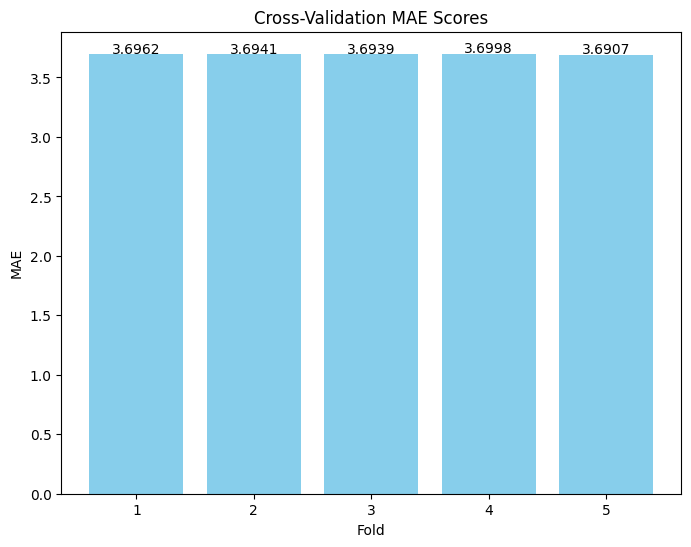

In [38]:
plt.figure(figsize=(8, 6))
plt.bar(range(1, 6), scores, color='skyblue')
plt.xlabel("Fold")
plt.ylabel("MAE")
plt.title("Cross-Validation MAE Scores")
plt.xticks(range(1, 6))
for i, score in enumerate(scores):
    plt.text(i + 1, score + 0.01, f"{score:.4f}", ha='center')  # Display scores above bars
plt.show()

## Box plot of cross-validation scores

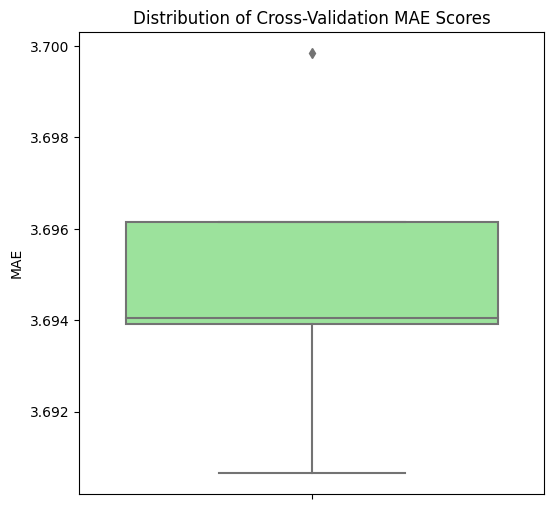

In [39]:
plt.figure(figsize=(6, 6))
sns.boxplot(y=scores, color='lightgreen')
plt.ylabel("MAE")
plt.title("Distribution of Cross-Validation MAE Scores")
plt.show()

# Create Submission File

## Predict with test data

In [40]:
# Predicts close prices 30 trading days after the last day of the training data.
tickers = df_train[df_train["Date"] == "2024-09-23"]["Ticker"]

In [41]:
X_test = df_train[df_train["Date"] == "2024-09-23"].drop(["Ticker", "future_close", "Date", "Stock Splits"], axis=1)

In [42]:
X_test.head()

,Open,High,Low,Close,Volume,Dividends,ret_1,ma_5,ma_10,ma_20,vol_5,vol_10,vol_20
21031592,103.680000,104.440002,103.290001,104.019997,1053600.0,0.0,0.006483,103.488000,103.903000,103.089000,0.010682,0.009075,0.009367
21033461,174.009995,175.190002,172.589996,173.770004,10265000.0,0.0,-0.002583,173.866000,174.583000,173.680000,0.011676,0.013016,0.010469
21032419,254.509995,256.929993,253.029999,256.649994,716200.0,0.0,0.009162,255.323999,252.629001,250.212501,0.013360,0.010468,0.010537
21030232,52.980000,53.279999,52.389999,52.980000,30500.0,0.0,0.012228,52.812000,52.227000,52.136500,0.014918,0.012041,0.012667
21033276,20.190001,20.350000,20.059999,20.290001,284600.0,0.0,0.016024,20.170000,20.184000,20.253500,0.017744,0.016692,0.013569


In [43]:
test_predictions = model.predict(X_test)

In [44]:
test_predictions

array([104.93756 , 175.15799 , 257.3591  , ..., 235.15114 ,   7.654241,
        91.60978 ], dtype=float32)

## Create DataFrame for Submission

In [45]:
df_result = X_test.copy()

In [46]:
df_result["ID"] = tickers

In [47]:
df_result["predicted_future_close"] = test_predictions

In [48]:
df_result["Pred"] = (df_result["predicted_future_close"] > df_result["Close"]).astype(int)

In [49]:
df_result.head()

,Open,High,Low,Close,Volume,Dividends,ret_1,ma_5,ma_10,ma_20,vol_5,vol_10,vol_20,ID,predicted_future_close,Pred
21031592,103.680000,104.440002,103.290001,104.019997,1053600.0,0.0,0.006483,103.488000,103.903000,103.089000,0.010682,0.009075,0.009367,ticker_1,104.937561,1
21033461,174.009995,175.190002,172.589996,173.770004,10265000.0,0.0,-0.002583,173.866000,174.583000,173.680000,0.011676,0.013016,0.010469,ticker_10,175.157990,1
21032419,254.509995,256.929993,253.029999,256.649994,716200.0,0.0,0.009162,255.323999,252.629001,250.212501,0.013360,0.010468,0.010537,ticker_100,257.359100,1
21030232,52.980000,53.279999,52.389999,52.980000,30500.0,0.0,0.012228,52.812000,52.227000,52.136500,0.014918,0.012041,0.012667,ticker_1000,52.589462,0
21033276,20.190001,20.350000,20.059999,20.290001,284600.0,0.0,0.016024,20.170000,20.184000,20.253500,0.017744,0.016692,0.013569,ticker_1001,20.223080,0


In [50]:
df_result.describe()

,Open,High,Low,Close,Volume,Dividends,ret_1,ma_5,ma_10,ma_20,vol_5,vol_10,vol_20,predicted_future_close,Pred
count,4990.000000,4990.000000,4990.000000,4990.000000,4.990000e+03,4990.0,4990.000000,4990.000000,4990.000000,4990.000000,4990.000000,4990.000000,4990.000000,4990.000000,4990.000000
mean,36.530164,36.899373,36.067551,36.461284,1.277788e+06,0.0,-0.004764,36.315850,35.819040,35.647627,0.025786,0.027122,0.028254,36.338001,0.695792
std,55.620487,56.169202,55.114281,55.708051,4.609641e+06,0.0,0.037494,55.180392,54.410179,54.037177,0.033389,0.034567,0.033927,54.281101,0.460117
min,0.095000,0.110000,0.085000,0.085000,0.000000e+00,0.0,-0.700812,0.105000,0.110380,0.107795,0.000000,0.000000,0.000000,0.408532,0.000000
25%,5.260000,5.362500,5.102500,5.182500,5.792500e+04,0.0,-0.014778,5.227500,5.249250,5.227375,0.010515,0.011383,0.012246,5.361983,0.000000
50%,16.245000,16.510000,15.950500,16.155000,2.584500e+05,0.0,-0.001026,16.210700,16.071450,15.932750,0.018447,0.019042,0.020350,16.294167,1.000000
75%,39.617499,39.902500,39.097499,39.377501,9.386750e+05,0.0,0.007386,39.528999,39.095250,38.757875,0.030539,0.032355,0.035179,39.600902,1.000000
max,424.359985,429.450012,422.000000,427.920013,1.844391e+08,0.0,0.805956,419.742004,415.836002,413.404001,1.022107,1.209275,1.143919,348.917572,1.000000


In [51]:
df_submission.head()

,ID,Pred
0,ticker_1,1
1,ticker_10,1
2,ticker_100,1
3,ticker_1000,1
4,ticker_1001,1


In [52]:
df_merged = pd.merge(df_submission.drop(["Pred"], axis=1), df_result[["ID", "Pred"]], on='ID', how='left')

In [53]:
df_merged.head()

,ID,Pred
0,ticker_1,1.0
1,ticker_10,1.0
2,ticker_100,1.0
3,ticker_1000,0.0
4,ticker_1001,0.0


In [54]:
df_merged.isnull().sum()

ID       0
Pred    10
dtype: int64

In [55]:
df_merged = df_merged.fillna(0)

In [56]:
df_merged.isnull().sum()

ID      0
Pred    0
dtype: int64

## Output csv

In [57]:
df_merged.to_csv("submission.csv", index=False)